In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
try:
    df = pd.read_csv('/kaggle/input/house-prices-bangalore2025/house_prices_bangalore.csv')
except FileNotFoundError:
    df = pd.read_csv("E:/Datasets/blore house/house_prices_bangalore.csv")

In [3]:
df.head()

,area,location,bhk,bath,balcony,parking,furnishing,property_type,age,price
0,2065,Bannerghatta Road,2,3,0,1,Semi-Furnished,Independent House,3,17280000
1,1539,Yelahanka,3,1,0,1,Unfurnished,Villa,8,9410000
2,2048,Bannerghatta Road,3,1,2,0,Semi-Furnished,Independent House,10,20300000
3,1233,Sarjapur Road,3,2,1,2,Fully-Furnished,Apartment,12,9060000
4,2487,Yelahanka,3,3,2,1,Fully-Furnished,Villa,4,28660000


In [4]:
df.isnull().sum()

area             0
location         0
bhk              0
bath             0
balcony          0
parking          0
furnishing       0
property_type    0
age              0
price            0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   area           1000 non-null   int64 
 1   location       1000 non-null   object
 2   bhk            1000 non-null   int64 
 3   bath           1000 non-null   int64 
 4   balcony        1000 non-null   int64 
 5   parking        1000 non-null   int64 
 6   furnishing     1000 non-null   object
 7   property_type  1000 non-null   object
 8   age            1000 non-null   int64 
 9   price          1000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 78.3+ KB


In [6]:
df.duplicated().sum()

0

## EDA

In [7]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
area,1000.0,1.648511e+03,4.879092e+02,803.0,1226.75,1648.0,2075.25,2499.0
bhk,1000.0,3.082000e+00,1.364235e+00,1.0,2.00,3.0,4.00,5.0
bath,1000.0,2.557000e+00,1.415187e+00,1.0,1.00,2.0,3.00,6.0
balcony,1000.0,1.012000e+00,8.028079e-01,0.0,0.00,1.0,2.00,2.0
parking,1000.0,9.650000e-01,8.345487e-01,0.0,0.00,1.0,2.00,2.0
age,1000.0,8.040000e+00,4.338805e+00,1.0,4.00,8.0,12.00,15.0
price,1000.0,1.237301e+07,5.386504e+06,2850000.0,8405000.00,11320000.0,15430000.00,32730000.0


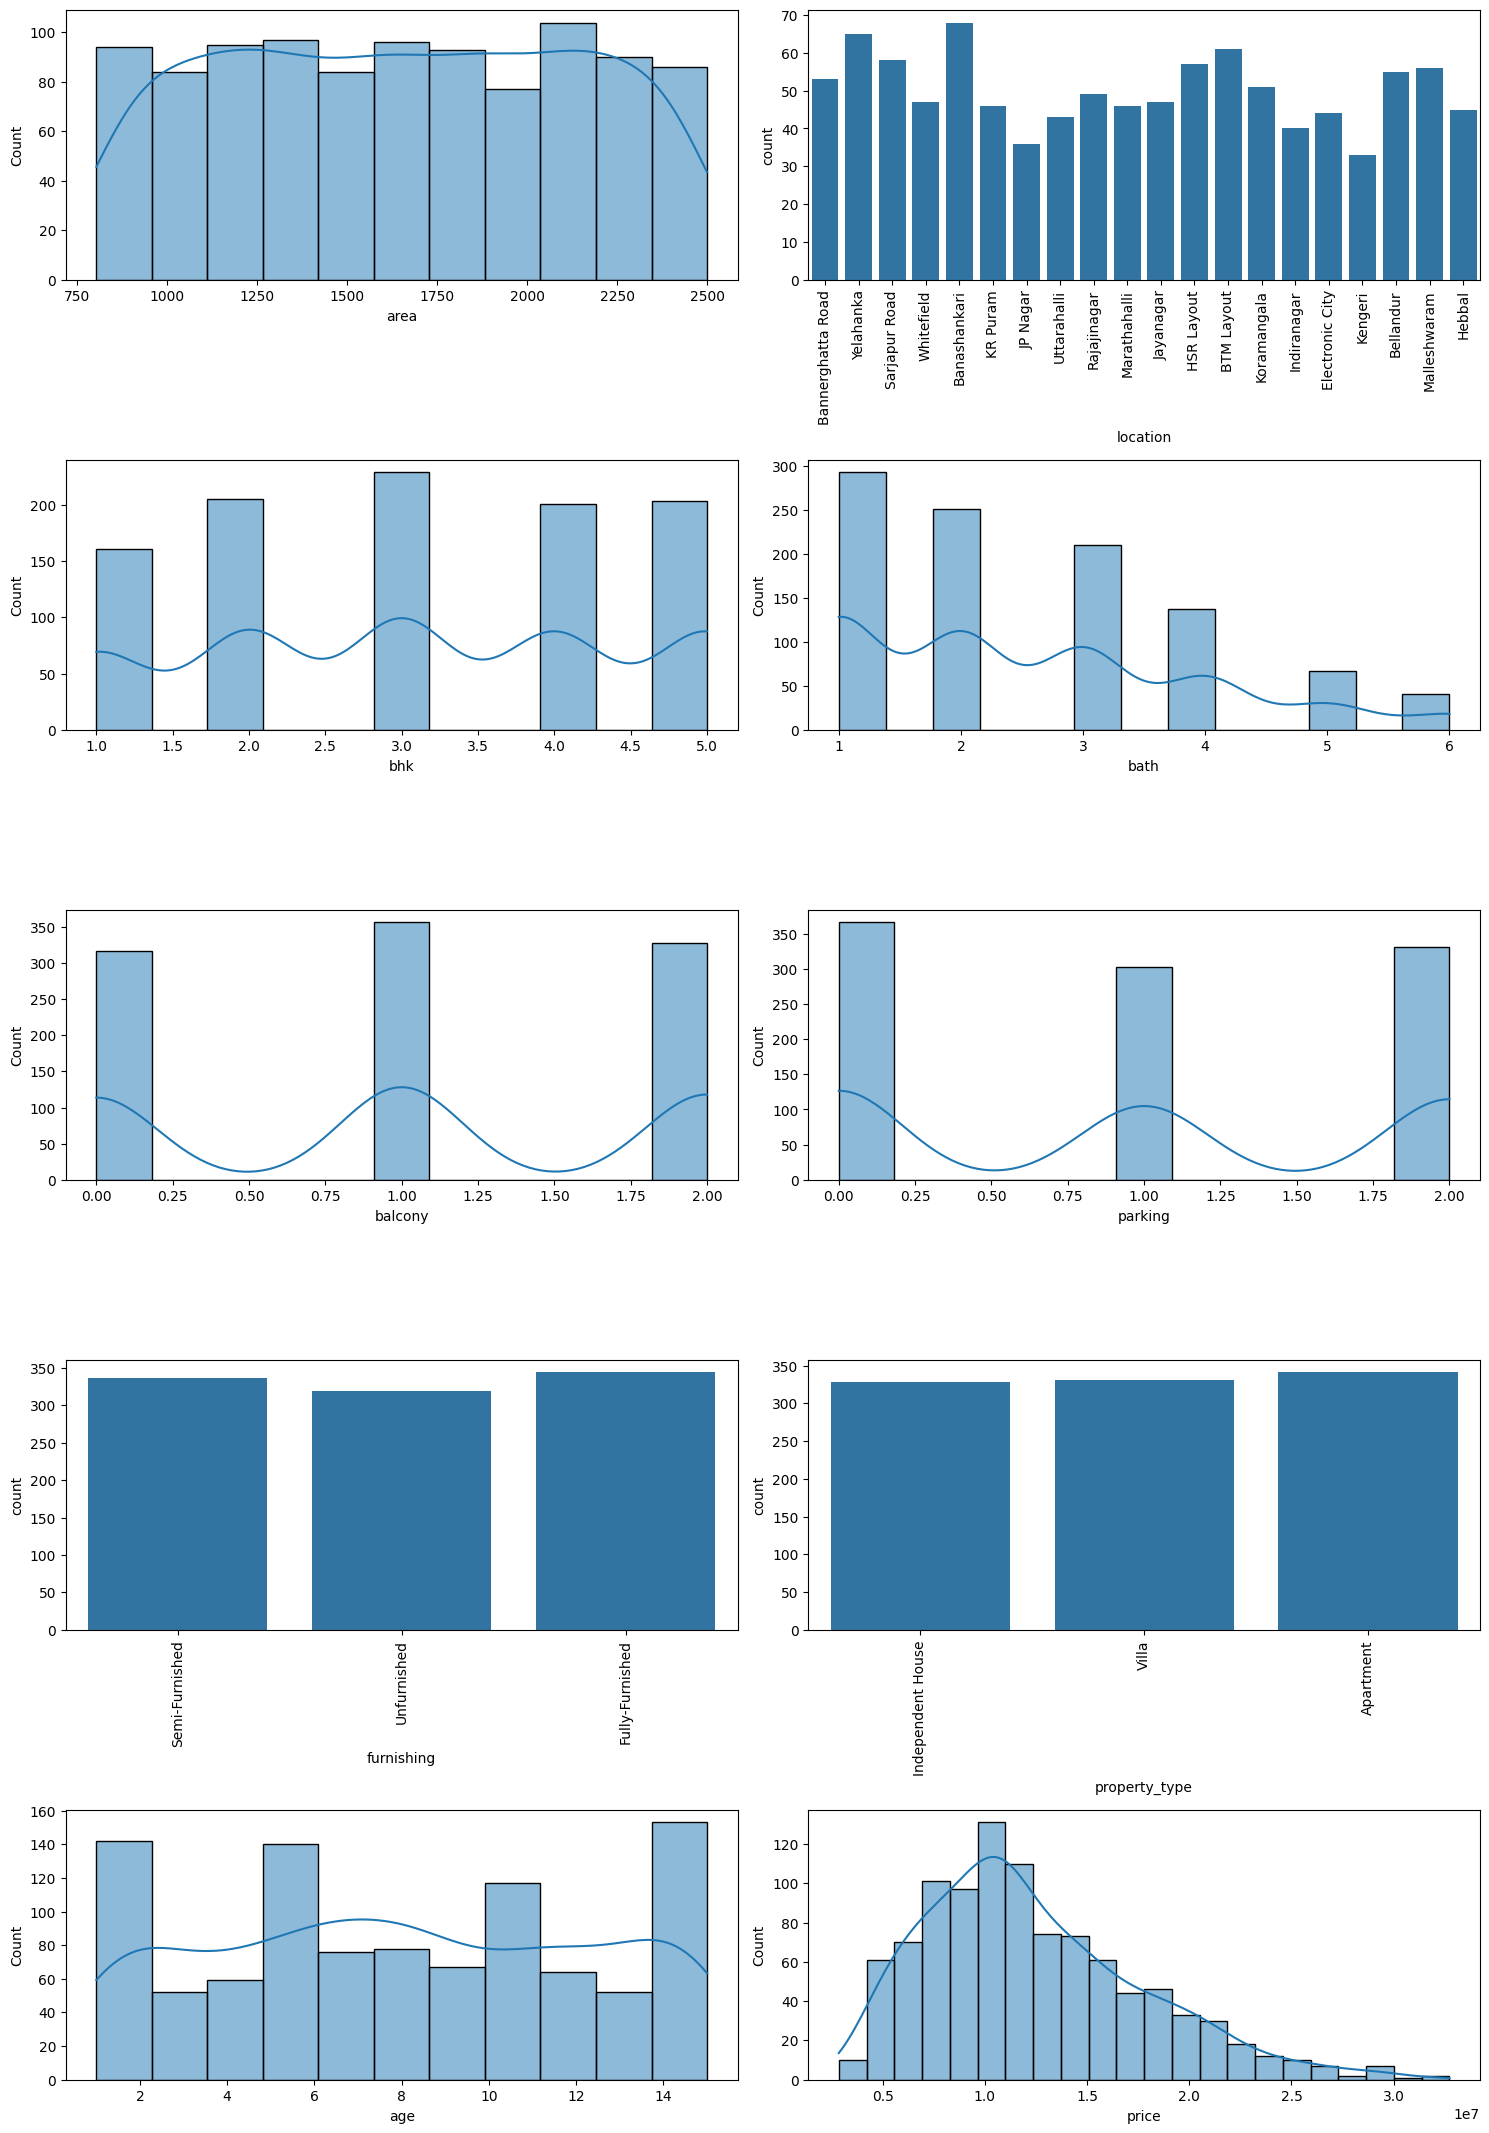

In [8]:
n = 1
plt.figure(figsize=(15, 30))
for i in df.columns:
    if n <= len(df.columns):
        if df[i].dtype == "int64":
            ax = plt.subplot(7, 2, n)
            sns.histplot(x= df[i], kde=True)
        else:
            ax = plt.subplot(7, 2, n)
            sns.countplot(x= df[i])
            plt.xticks(rotation = 90)
    n += 1
plt.tight_layout()
plt.show()

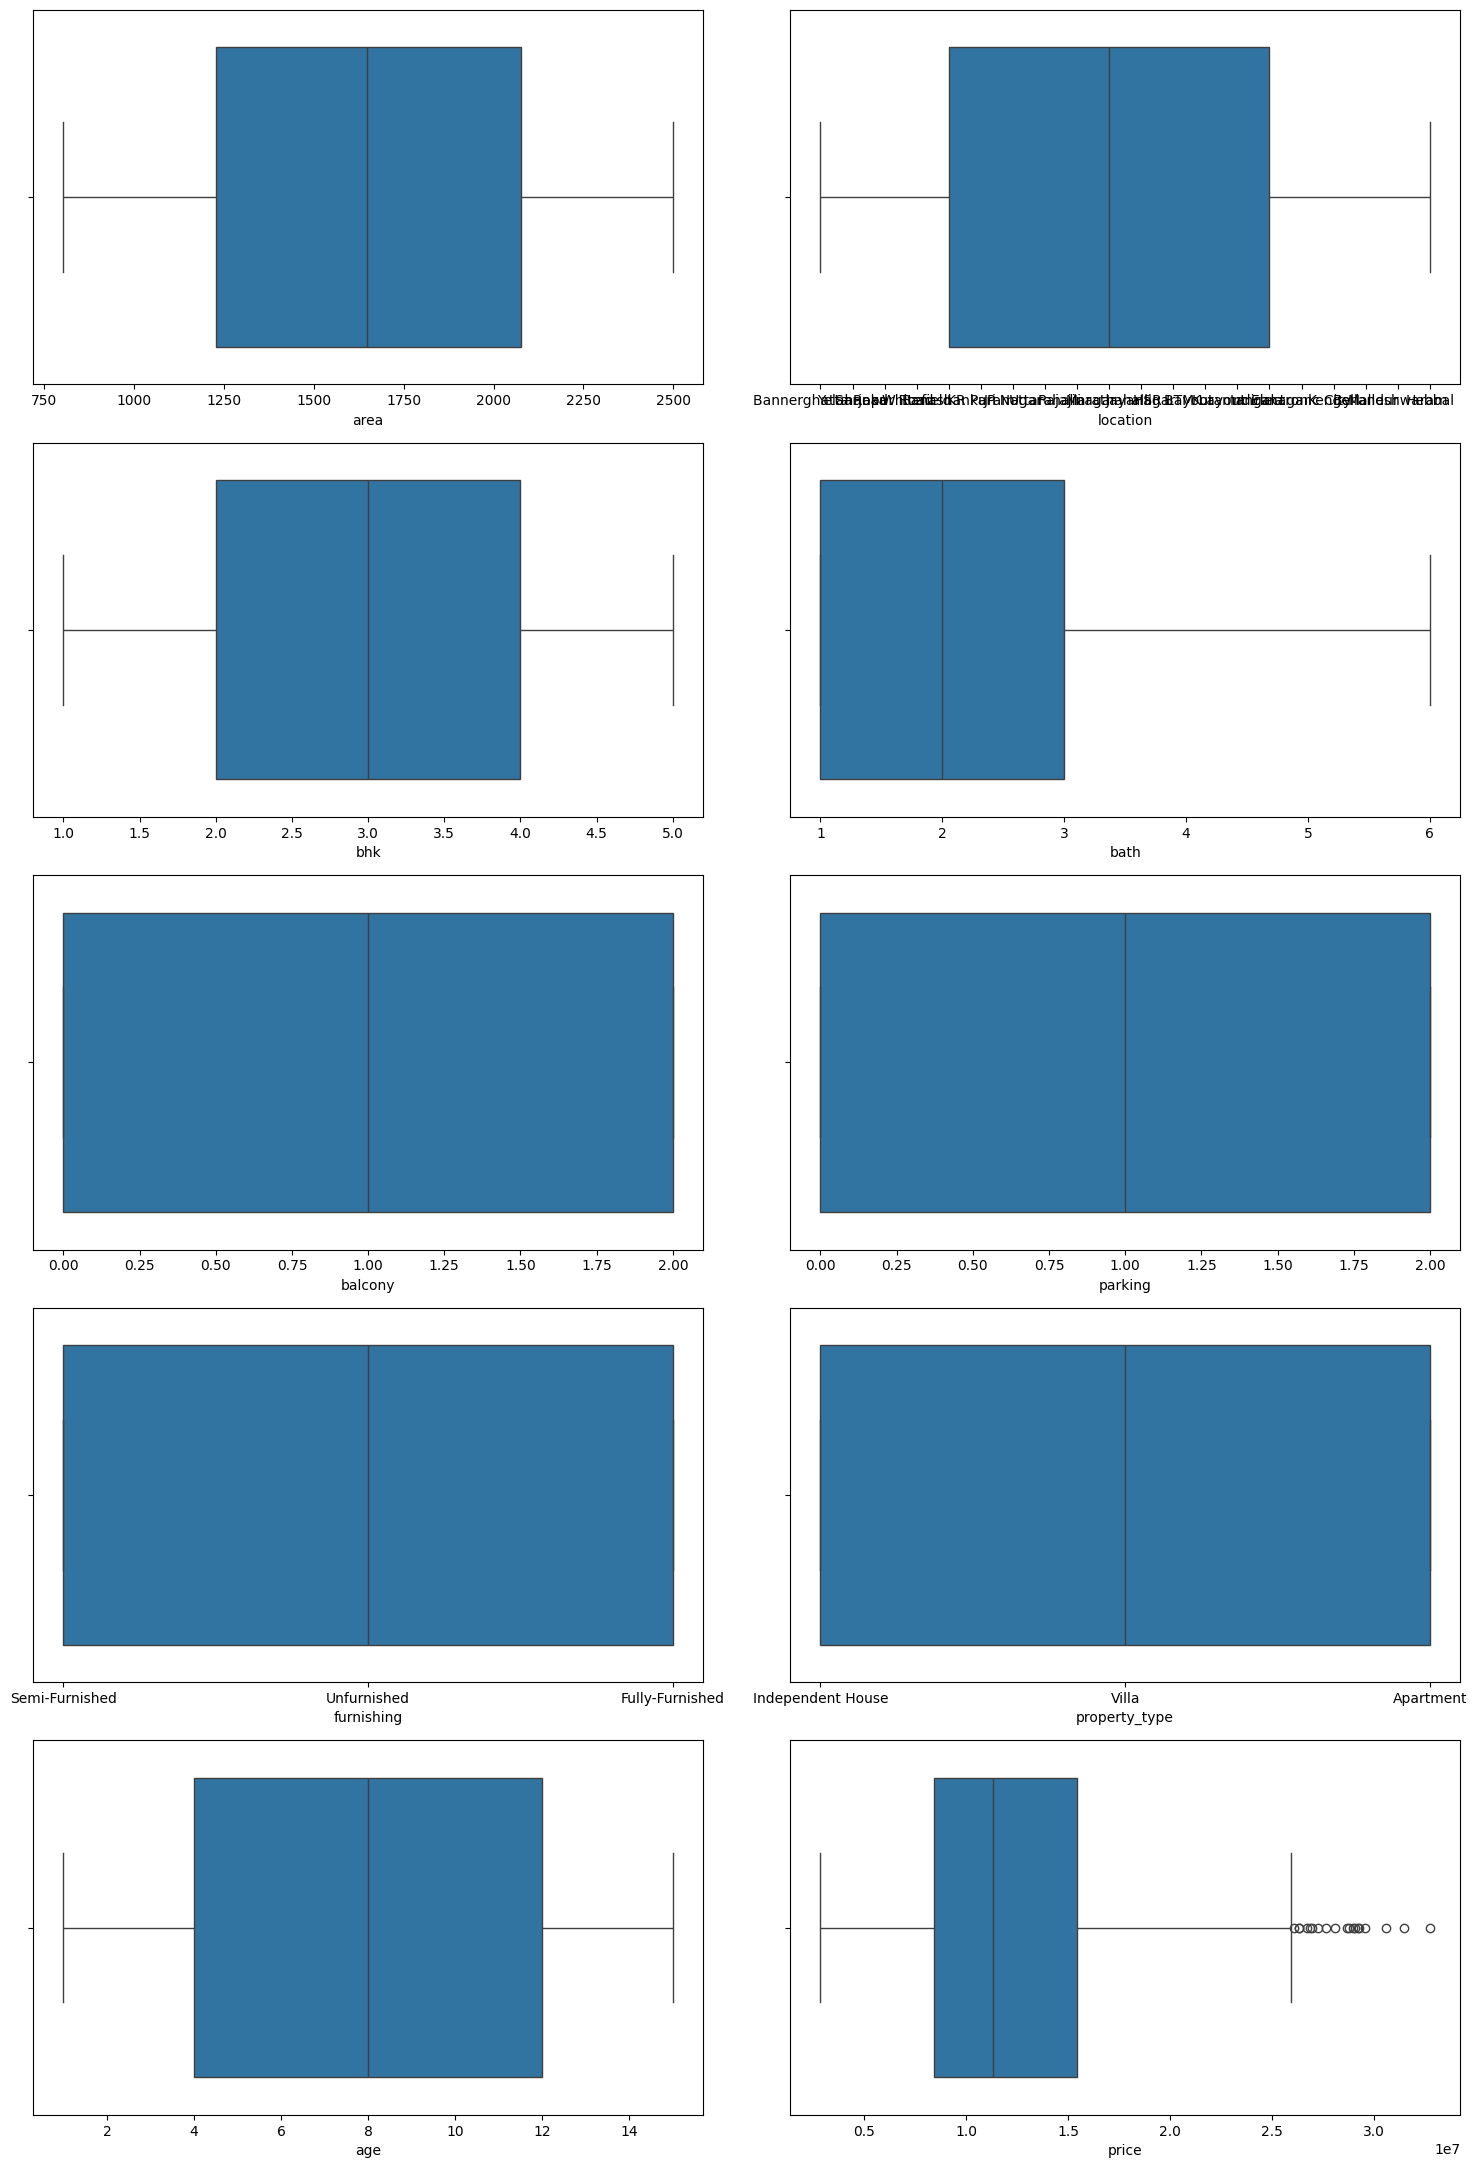

In [9]:
n = 1
plt.figure(figsize=(15, 30))
for i in df.columns:
    if n <= len(df.columns):
        ax = plt.subplot(7, 2, n)
        sns.boxplot(x= df[i])
    n += 1
plt.tight_layout()
plt.show()

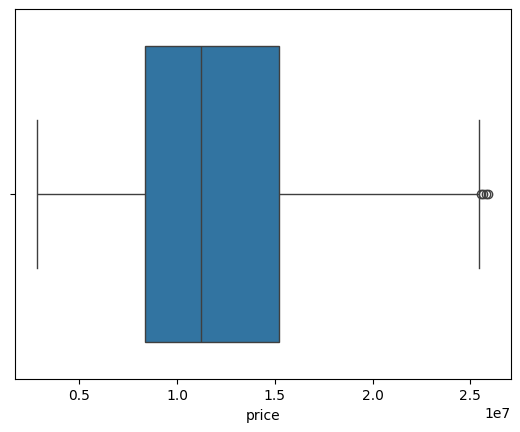

In [10]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 -q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

df = df[(df['price'] >= lower) & (df['price'] <= upper)]


sns.boxplot(x=df['price'])
plt.show()

### Feature Engineering

In [11]:
# Categorical Encoding
print(df['location'].value_counts())
print(df['furnishing'].value_counts())
print(df['property_type'].value_counts())

location
Banashankari         66
Yelahanka            63
BTM Layout           61
Sarjapur Road        58
HSR Layout           56
Bannerghatta Road    53
Malleshwaram         53
Bellandur            53
Koramangala          50
Jayanagar            47
Rajajinagar          46
Marathahalli         46
KR Puram             46
Whitefield           46
Hebbal               45
Uttarahalli          43
Electronic City      42
Indiranagar          40
JP Nagar             34
Kengeri              33
Name: count, dtype: int64
furnishing
Semi-Furnished     335
Fully-Furnished    329
Unfurnished        317
Name: count, dtype: int64
property_type
Apartment            341
Independent House    326
Villa                314
Name: count, dtype: int64


In [12]:
# Encoding on location column
df.loc[df['location'] == 'Banashankari', 'location'] = 'south'
df.loc[df['location'] == 'Yelahanka', 'location'] = 'north'
df.loc[df['location'] == 'BTM Layout', 'location'] = 'south'
df.loc[df['location'] == 'Sarjapur Road', 'location'] = 'south_east'
df.loc[df['location'] == 'HSR Layout', 'location'] = 'south_east'
df.loc[df['location'] == 'Malleshwaram', 'location'] = 'west'
df.loc[df['location'] == 'Bellandur', 'location'] = 'south_east'
df.loc[df['location'] == 'Bannerghatta Road', 'location'] = 'south'
df.loc[df['location'] == 'Koramangala', 'location'] = 'central'
df.loc[df['location'] == 'Rajajinagar', 'location'] = 'west'
df.loc[df['location'] == 'Whitefield', 'location'] = 'east'
df.loc[df['location'] == 'Jayanagar', 'location'] = 'south'
df.loc[df['location'] == 'Marathahalli', 'location'] = 'east'
df.loc[df['location'] == 'KR Puram', 'location'] = 'north_east'
df.loc[df['location'] == 'Hebbal', 'location'] = 'north'
df.loc[df['location'] == 'Electronic City', 'location'] = 'south'
df.loc[df['location'] == 'Uttarahalli', 'location'] = 'south_west'
df.loc[df['location'] == 'Indiranagar', 'location'] = 'east'
df.loc[df['location'] == 'JP Nagar', 'location'] = 'south'
df.loc[df['location'] == 'Kengeri', 'location'] = 'south_west'

zone_map = {
    'north': 0,
    'south': 1,
    'east': 2,
    'west': 3,
    'central': 4,
    'north_east': 5,
    'south_east': 6,
    'south_west': 7
}

df['location'] = df['location'].map(zone_map).astype(int)

print(df['location'].value_counts())

location
1    303
6    167
2    132
0    108
3     99
7     76
4     50
5     46
Name: count, dtype: int64


In [13]:
# One hot encoding on furnishing column
df.loc[df['furnishing'] == 'Fully-Furnished', 'furnishing'] = 3
df.loc[df['furnishing'] == 'Semi-Furnished', 'furnishing'] = 2
df.loc[df['furnishing'] == 'Unfurnished', 'furnishing'] = 1
df['furnishing'] = df['furnishing'].astype(int)
df['furnishing'].value_counts()

furnishing
2    335
3    329
1    317
Name: count, dtype: int64

In [14]:
df.loc[df['property_type'] == 'Apartment', 'property_type'] = 1
df.loc[df['property_type'] == 'Villa', 'property_type'] = 2
df.loc[df['property_type'] == 'Independent House', 'property_type'] = 3
df['property_type'] = df['property_type'].astype(int)
df['property_type'].value_counts()

property_type
1    341
3    326
2    314
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   area           981 non-null    int64
 1   location       981 non-null    int32
 2   bhk            981 non-null    int64
 3   bath           981 non-null    int64
 4   balcony        981 non-null    int64
 5   parking        981 non-null    int64
 6   furnishing     981 non-null    int32
 7   property_type  981 non-null    int32
 8   age            981 non-null    int64
 9   price          981 non-null    int64
dtypes: int32(3), int64(7)
memory usage: 72.8 KB


In [16]:
df.corr()

,area,location,bhk,bath,balcony,parking,furnishing,property_type,age,price
area,1.000000,-0.037107,-0.001695,0.039493,-0.004686,-0.064416,-0.077435,0.077871,-0.010949,0.686581
location,-0.037107,1.000000,0.014281,0.016240,-0.052393,-0.091579,0.030074,-0.060236,0.001411,-0.070793
bhk,-0.001695,0.014281,1.000000,0.529470,0.013747,0.054847,-0.013750,-0.009736,0.012095,0.025299
bath,0.039493,0.016240,0.529470,1.000000,0.050165,0.039260,-0.020944,0.013316,-0.001173,0.038568
balcony,-0.004686,-0.052393,0.013747,0.050165,1.000000,0.043424,0.042081,0.006532,0.000105,0.034755
parking,-0.064416,-0.091579,0.054847,0.039260,0.043424,1.000000,0.030664,0.017101,-0.050514,-0.023941
furnishing,-0.077435,0.030074,-0.013750,-0.020944,0.042081,0.030664,1.000000,-0.036293,0.038586,0.131958
property_type,0.077871,-0.060236,-0.009736,0.013316,0.006532,0.017101,-0.036293,1.000000,0.019244,0.158188
age,-0.010949,0.001411,0.012095,-0.001173,0.000105,-0.050514,0.038586,0.019244,1.000000,-0.005123
price,0.686581,-0.070793,0.025299,0.038568,0.034755,-0.023941,0.131958,0.158188,-0.005123,1.000000


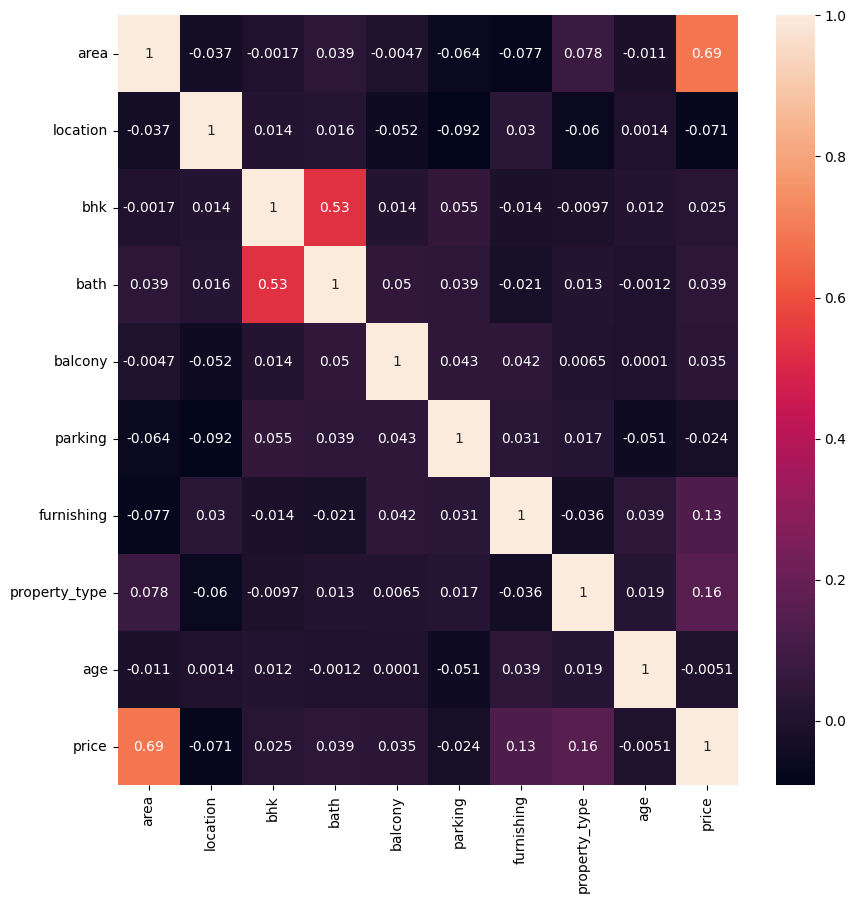

In [17]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True)
plt.show()

### Model Creation

In [18]:
# defining x and y
x = df.drop(columns='price')
y = np.log1p(df['price'])
x.shape

(981, 9)

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [20]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=400,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.9,
    random_state=42)
gbr.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",400
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.9
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [21]:
y_pred1 = gbr.predict(x_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred1))
print("MSE:", mean_squared_error(y_test, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))
print("R2 Score:", r2_score(y_test, y_pred1))

MAE: 0.23575812096180648
MSE: 0.08136900648615768
RMSE: 0.2852525310775659
R2 Score: 0.5474961138162557


In [23]:
# XGBoost Model
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42)
xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [24]:
y_pred2 = xgb.predict(x_test)

In [25]:

print("MAE:", mean_absolute_error(y_test, y_pred2))
print("MSE:", mean_squared_error(y_test, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))
print("R2 Score:", r2_score(y_test, y_pred2))

MAE: 0.24000911221954385
MSE: 0.08746687426830879
RMSE: 0.29574799114839107
R2 Score: 0.5135850586366961


### Model Performance Conclusion

#### The Gradient Boosting Regressor achieved an R² score of ~0.55, indicating it explains around 55% of the variance in house prices on the test set. XGBoost with tuned hyperparameters achieved a slightly lower R² of ~0.51, suggesting that for this relatively small dataset, simpler boosting methods generalize better. Overall, the results provide a strong and honest baseline for price prediction, with further improvements possible through richer feature engineering and additional data.